In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
df=pd.read_csv("Gold Price.csv")
df

,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77
...,...,...,...,...,...,...,...
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   str    
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), str(1)
memory usage: 169.9 KB


In [4]:
df.shape

(3104, 7)

In [5]:
df.head(5)


,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77


In [6]:
df.tail(5)

,Date,Price,Open,High,Low,Volume,Chg%
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3103,2014-01-01,29542,29435,29598,29340,2930,0.25


In [7]:
df.isnull().sum()

Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
Chg%      0
dtype: int64

In [8]:
df.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


In [9]:
#correlation:-there are two types of correlation which are as follows:-
#positive:- one value increasing other also increasing(directly proportional)
#negative:-inversely proportional

In [10]:
df.corr(numeric_only=True)

,Price,Open,High,Low,Volume,Chg%
Price,1.000000,0.999803,0.999892,0.999927,0.475516,0.070896
Open,0.999803,1.000000,0.999904,0.999873,0.476181,0.055086
High,0.999892,0.999904,1.000000,0.999843,0.479422,0.063111
Low,0.999927,0.999873,0.999843,1.000000,0.471945,0.064449
Volume,0.475516,0.476181,0.479422,0.471945,1.000000,-0.014897
Chg%,0.070896,0.055086,0.063111,0.064449,-0.014897,1.000000


In [11]:
# 0.9=1 positive correlation
# 0.06=0 moderate correlation
#-0.01 is negative correlation

In [12]:
corr=df.corr(numeric_only=True)
corr[corr>0]                          #this will replace negative values with Nan

,Price,Open,High,Low,Volume,Chg%
Price,1.000000,0.999803,0.999892,0.999927,0.475516,0.070896
Open,0.999803,1.000000,0.999904,0.999873,0.476181,0.055086
High,0.999892,0.999904,1.000000,0.999843,0.479422,0.063111
Low,0.999927,0.999873,0.999843,1.000000,0.471945,0.064449
Volume,0.475516,0.476181,0.479422,0.471945,1.000000,NaN
Chg%,0.070896,0.055086,0.063111,0.064449,NaN,1.000000


In [13]:
corr=df.corr(numeric_only=True)
corr[corr<0]                                     #this will replace all positive value with Nan

,Price,Open,High,Low,Volume,Chg%
Price,NaN,NaN,NaN,NaN,NaN,NaN
Open,NaN,NaN,NaN,NaN,NaN,NaN
High,NaN,NaN,NaN,NaN,NaN,NaN
Low,NaN,NaN,NaN,NaN,NaN,NaN
Volume,NaN,NaN,NaN,NaN,NaN,-0.014897
Chg%,NaN,NaN,NaN,NaN,-0.014897,NaN


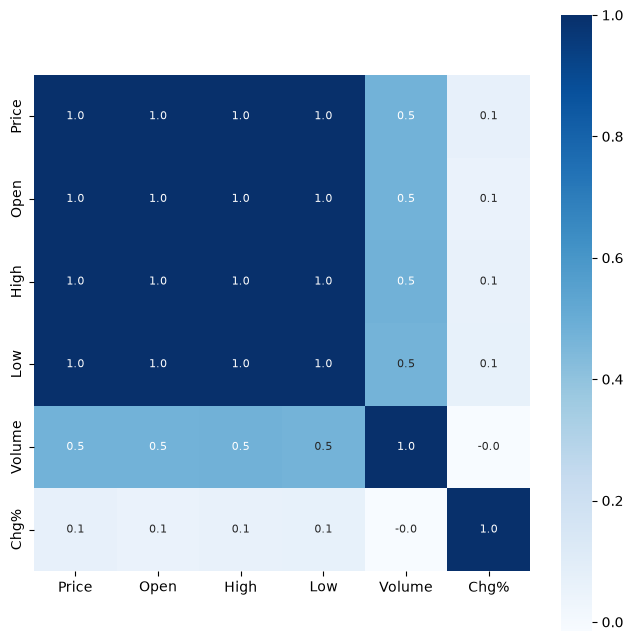

In [14]:
#constructing heat map to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(corr,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')
plt.show()

Price     1.000000
Open      0.999803
High      0.999892
Low       0.999927
Volume    0.475516
Chg%      0.070896
Name: Price, dtype: float64


<Axes: xlabel='Price', ylabel='Count'>

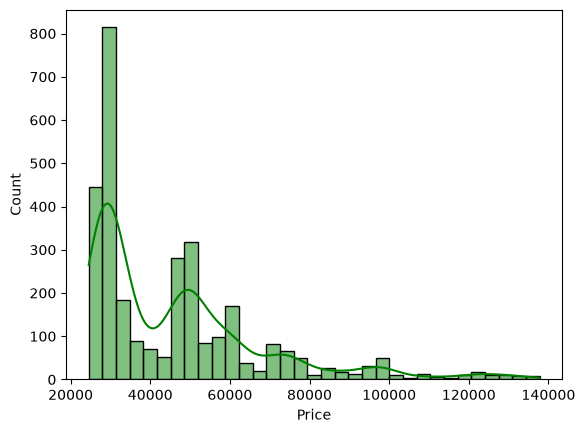

In [15]:
print(corr['Price'])
sns.histplot(df['Price'],kde=True,color='Green')

In [16]:
import matplotlib.pyplot as plt

In [17]:
df['Year']=df['Date'].str.slice(0,4)

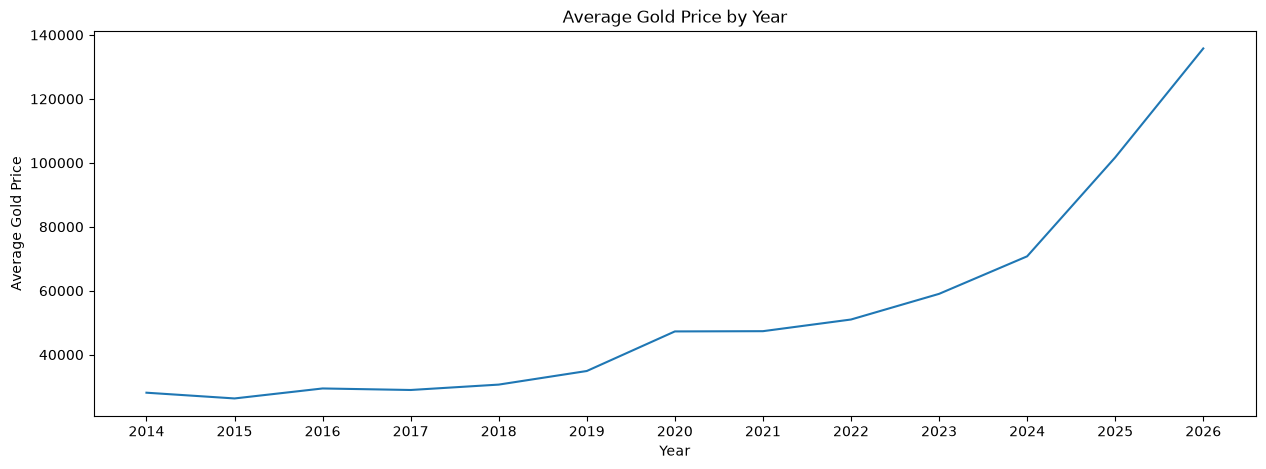

In [18]:
yearly = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(15,5))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Average Gold Price")
plt.title("Average Gold Price by Year")
plt.show()

In [19]:
X=df.drop(['Date','Price','Year'],axis=1)
Y=df['Price']

In [20]:
print(X)

        Open    High     Low  Volume  Chg%
0     136143  137037  135525   51877  0.02
1     135687  135850  135001   14622  0.23
2     136526  136527  134866   59050  1.10
3     133185  134880  132853   36733  1.04
4     137628  138269  131695   90640 -3.77
...      ...     ...     ...     ...   ...
3099   29300   29395   29051   24380 -0.55
3100   29279   29279   29279       0 -1.51
3101   30031   30125   29539    3050 -0.83
3102   29678   30050   29678    3140  1.47
3103   29435   29598   29340    2930  0.25

[3104 rows x 5 columns]


In [21]:
print(Y)

0       135793
1       135771
2       135454
3       133974
4       132595
         ...  
3099     29119
3100     29279
3101     29727
3102     29975
3103     29542
Name: Price, Length: 3104, dtype: int64


In [22]:
X_train,X_test,Y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [23]:
regressor= RandomForestRegressor(n_estimators=100)

In [24]:
#training the model
regressor.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [25]:
#Model Evaluation
#prediction on test data
test_data_prediction=regressor.predict(X_test)

In [26]:
print(test_data_prediction)

[ 34958.28  28469.56  78156.52  57246.52  45717.05  50761.28  29757.1
  60073.69  47955.1   56176.38  47604.39  75718.37  37640.22  71433.83
  25628.49  71767.24 128740.85  30518.97  30643.08  38019.66  27084.1
  77617.87  62242.37  88712.59  29935.65  30469.85  26908.06  60178.27
  50679.89  47552.63  29194.74  27237.04  27698.01  58160.89  55269.44
  55405.07  29579.49  26703.98  53812.75  90580.24  29183.92  24739.89
  29657.79  49500.    60997.85  44794.14  37515.8   30887.87  26391.81
  25972.91  37614.27  60604.68  71586.4   51303.45  68376.7   40625.99
  74059.86  25755.58  71013.46  73362.36  57490.39  62589.84  26443.02
  51250.3   25885.43  26183.59  31471.5   85749.58  29947.48  30741.08
  32227.75  96748.7   28502.64  29383.43  95411.89  75538.21  29038.14
  52274.7   89406.28  27289.17  28583.62 121825.76  28428.05 119148.13
  40272.98  92884.75  30471.8   29797.72  50856.13  28784.02 127347.94
  50554.95  31141.48  96591.6   77223.46 101146.34  29187.75  46801.45
  28769.

In [27]:
#R squared error
error_score=metrics.r2_score(y_test,test_data_prediction)
print("R squared error:",error_score)

R squared error: 0.9998884035257134


In [28]:
#compare actual value and predicted value in a plot
y_test=list(y_test)

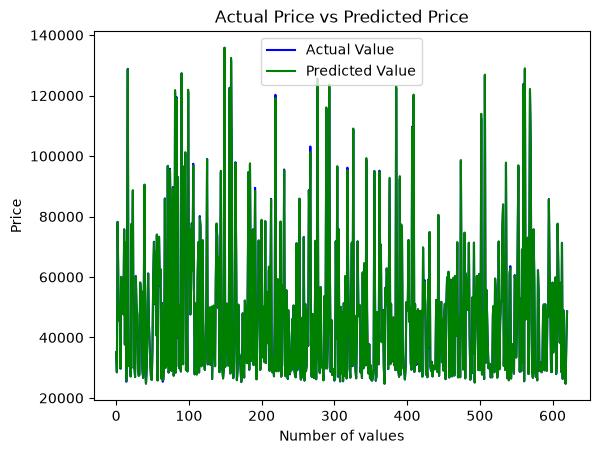

In [29]:
plt.plot(y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('Price')
plt.legend()
plt.show()

In [30]:
print("\n====== Gold Price Prediction ======\n")

open_price = float(input("Enter Open Price: "))
high_price = float(input("Enter High Price: "))
low_price = float(input("Enter Low Price: "))
volume = float(input("Enter Volume: "))
change = float(input("Enter Change %: "))

user_data = [[open_price, high_price, low_price, volume, change]]

prediction = regressor.predict(user_data)

print("\n========== RESULT ==========")
print("Open Price   :", open_price)
print("High Price   :", high_price)
print("Low Price    :", low_price)
print("Volume       :", volume)
print("Change %     :", change)
print("----------------------------")
print("Predicted Gold Price : ₹", round(prediction[0],2))
print("============================")


====== Gold Price Prediction ======



Enter Open Price:  50000
Enter High Price:  55000
Enter Low Price:  49000
Enter Volume:  25000
Enter Change %:  0.8



========== RESULT ==========
Open Price   : 50000.0
High Price   : 55000.0
Low Price    : 49000.0
Volume       : 25000.0
Change %     : 0.8
----------------------------
Predicted Gold Price : ₹ 51834.94


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [1]:
import tkinter as tk
from tkinter import messagebox

# Function to predict gold price
def predict_price():
    try:
        open_price = float(open_entry.get())
        high_price = float(high_entry.get())
        low_price = float(low_entry.get())
        volume = float(volume_entry.get())
        change = float(change_entry.get())

        user_data = [[open_price, high_price, low_price, volume, change]]

        prediction = regressor.predict(user_data)

        result_label.config(
            text=f"Predicted Gold Price: ₹ {prediction[0]:.2f}",
            fg="green"
        )

    except:
        messagebox.showerror("Error", "Please enter valid values.")

# Clear all entries
def clear_data():
    open_entry.delete(0, tk.END)
    high_entry.delete(0, tk.END)
    low_entry.delete(0, tk.END)
    volume_entry.delete(0, tk.END)
    change_entry.delete(0, tk.END)
    result_label.config(text="")

# Window
root = tk.Tk()
root.title("Gold Price Prediction")
root.geometry("450x450")

title = tk.Label(root,
                 text="Gold Price Prediction",
                 font=("Arial",18,"bold"))
title.pack(pady=10)

tk.Label(root,text="Open Price").pack()
open_entry = tk.Entry(root,width=25)
open_entry.pack()

tk.Label(root,text="High Price").pack()
high_entry = tk.Entry(root,width=25)
high_entry.pack()

tk.Label(root,text="Low Price").pack()
low_entry = tk.Entry(root,width=25)
low_entry.pack()

tk.Label(root,text="Volume").pack()
volume_entry = tk.Entry(root,width=25)
volume_entry.pack()

tk.Label(root,text="Change %").pack()
change_entry = tk.Entry(root,width=25)
change_entry.pack()

tk.Button(root,
          text="Predict",
          command=predict_price,
          bg="green",
          fg="white").pack(pady=10)

tk.Button(root,
          text="Clear",
          command=clear_data,
          bg="orange").pack()

result_label = tk.Label(root,
                        text="",
                        font=("Arial",14,"bold"))
result_label.pack(pady=20)

tk.Button(root,
          text="Exit",
          command=root.destroy,
          bg="red",
          fg="white").pack()

root.mainloop()